<div align="center">

# Universidad de Sevilla  
## Grado en Ingeniería del Software  
### Escuela Técnica Superior de Ingeniería Informática  
### Inteligencia Artificial (IA) – Curso 2024/2025  

<img src="../../img/portada.png" width="300"/>

---

#  Ensamble Secuencial de Modelos Predictivos  
### Primera Convocatoria – Junio 2025  

**Profesor:** Juan Galán Páez  
**Autores:**  
Carlos Martín de Prado Barragán  
Marco Padilla Gómez  

**Fecha de entrega:** 9 de Junio de 2025  

</div>

## Introducción

El objetivo de este notebook es implementar y evaluar un meta-modelo de ensamble secuencial para tareas de regresión, utilizando el conjunto de datos  que contiene informacion sobre viviendas que han sido vendidas a traves de una agencia inmobiliaria.

Este tipo de modelo se construye mediante la combinación iterativa de varios modelos base, donde cada nuevo modelo aprende a corregir los errores residuales cometidos por los anteriores, lo que permite mejorar la capacidad predictiva y la generalización.

Se emplea el `DecisionTreeRegressor` como modelo base por su capacidad para capturar relaciones no lineales, y se utilizan técnicas de preprocesamiento como la estandarización de variables para normalizar las escalas y facilitar el entrenamiento.

La evaluación inicial se realiza mediante la métrica de coeficiente de determinación R² sobre un conjunto de prueba, que mide la proporción de variabilidad explicada por el modelo. En notebooks posteriores se implementará validación cruzada para evaluar la estabilidad y robustez del modelo.

Este enfoque está inspirado en técnicas de boosting y proporciona un marco flexible y escalable para resolver problemas de regresión complejos.

## 1. Importación de librerías 

En esta sección se importan todas las librerías necesarias para el proyecto:

- `numpy` y `pandas` para manipulación y análisis de datos.
- Módulos de `scikit-learn` para:
  - Modelos de regresión (`DecisionTreeRegressor`).
  - Preprocesamiento de datos (`StandardScaler`,`OneHotEncoder`).
  - División de datos en entrenamiento y prueba (`train_test_split`).
  - Métricas de evaluación (`r2_score`).
  - Transformación de las columnas(`ColumnTransformer`)
- Además, se importa el meta-modelo `SequentialEnsembleRegressor` que implementamos en el módulo `sequential_ensemble.py`.

In [1]:
# Importación de librerías necesarias
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer

# Importar el meta-modelo desde nuestro módulo
import sys
sys.path.append('../../src')

from sequential_ensemble import SequentialEnsembleRegressor

## 2. Carga y exploración inicial del dataset

En esta sección se carga el conjunto de datos `house_prices.csv` desde la carpeta `data`.  
A continuación, se muestra información general del DataFrame, incluyendo:

- El número de filas y columnas.
- El tipo de datos de cada columna.
- Los primeros registros del conjunto para una inspección visual rápida.

In [2]:
# Cargar el dataset desde la carpeta 'data'
df = pd.read_csv("../../data/house_prices.csv")

# Mostrar información general
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   GarageCars     560 non-null    int64  
 1   Condition2     560 non-null    object 
 2   YearBuilt      560 non-null    int64  
 3   GarageYrBlt    560 non-null    float64
 4   LandContour    560 non-null    object 
 5   LowQualFinSF   560 non-null    int64  
 6   HouseStyle     560 non-null    object 
 7   GarageType     560 non-null    object 
 8   MSSubClass     560 non-null    int64  
 9   WoodDeckSF     560 non-null    int64  
 10  FireplaceQu    560 non-null    object 
 11  BsmtFinSF2     560 non-null    int64  
 12  Alley          560 non-null    object 
 13  MSZoning       560 non-null    object 
 14  OverallCond    560 non-null    int64  
 15  EnclosedPorch  560 non-null    int64  
 16  CentralAir     560 non-null    object 
 17  LotFrontage    560 non-null    float64
 18  GarageCond

,GarageCars,Condition2,YearBuilt,GarageYrBlt,LandContour,LowQualFinSF,HouseStyle,GarageType,MSSubClass,WoodDeckSF,...,MiscVal,BsmtExposure,OpenPorchSF,ExterCond,Fireplaces,FullBath,BsmtQual,MiscFeature,PoolQC,SalePrice
0,2,Norm,1962,1977.0,Lvl,0,1Story,Detchd,20,0,...,0,none,0,TA,0,1,TA,none,none,132000
1,0,Norm,1914,0.0,Lvl,0,2.5Unf,none,75,0,...,0,none,291,TA,1,2,TA,none,none,128000
2,2,Norm,1999,1999.0,Lvl,0,1Story,Attchd,20,0,...,0,Av,35,TA,0,2,Gd,none,none,192000
3,1,Norm,1948,1948.0,Bnk,0,2Story,Attchd,20,103,...,0,none,0,Gd,0,3,TA,none,none,225000
4,2,Norm,1950,1950.0,Lvl,0,1Story,Detchd,20,0,...,0,none,29,TA,0,1,none,none,none,109900


## 3. Preprocesamiento de los datos

En este paso se realiza la preparación de los datos para el entrenamiento del meta-modelo:

- Se separan las variables predictoras (`X`) y la variable objetivo (`y`), que en este caso es `SalePrice`.
- Las variables numéricas se estandarizan utilizando `StandardScaler`, que normaliza los valores para que tengan media 0 y desviación estándar 1, mejorando así el rendimiento y estabilidad del modelo.
- Las variables categóricas presentes en el conjunto de datos (`object`) se codifican numéricamente mediante `OneHotEncoder`, creando columnas binarias para cada categoría.
- El conjunto de datos estandarizado se divide en conjuntos de entrenamiento (80%) y prueba (20%) mediante `train_test_split`, asegurando una evaluación objetiva del modelo.
- Se convierte `y_train` a un array de NumPy para evitar problemas de indexación con pandas durante el entrenamiento del meta-modelo.

In [3]:
# Separar variables predictoras y variable objetivo
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Detectar variables categóricas (tipo objeto) y numéricas
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])
X_processed = preprocessor.fit_transform(X)

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Evitar errores de indexación
y_train = y_train.to_numpy()

## 4. Creación y entrenamiento del meta-modelo secuencial

En esta sección se crea una instancia del `SequentialEnsembleRegressor` utilizando como estimador base un árbol de decisión (`DecisionTreeRegressor`).  
Los hiperparámetros configurados son:

- `n_estimators=50`: se entrenan 50 modelos secuenciales para mejorar la predicción.
- `lr=0.1`: tasa de aprendizaje que modula la influencia de cada modelo individual.
- `sample_size=0.75`: cada modelo se entrena con el 75% de los datos seleccionados aleatoriamente sin reemplazo.
- `est_params={"max_depth": 4}`: se limita la profundidad máxima del árbol para controlar su complejidad.
- `random_state=42`: semilla para asegurar la reproducibilidad del experimento.

Finalmente, se entrena el meta-modelo con los datos de entrenamiento escalados y preparados.

In [4]:
# Crear y entrenar el meta-modelo con árboles de decisión
modelo = SequentialEnsembleRegressor(
    base_estimator=DecisionTreeRegressor,
    n_estimators=50,
    lr=0.1,
    sample_size=0.75,
    est_params={"max_depth": 4},
    random_state=42
)

modelo.fit(X_train, y_train)

SequentialEnsembleRegressor(base_estimator=<class 'sklearn.tree._classes.DecisionTreeRegressor'>,
                            est_params={'max_depth': 4}, n_estimators=50,
                            random_state=42, sample_size=0.75)

## 5. Predicción y evaluación del modelo

En esta última sección se generan las predicciones del meta-modelo sobre el conjunto de prueba (`X_test`).  
A continuación, se evalúa la calidad de las predicciones calculando el coeficiente de determinación R², que mide qué proporción de la variabilidad en la variable objetivo es explicada por el modelo.

Un valor de R² cercano a 1 indica un buen ajuste del modelo a los datos de prueba.

In [5]:
# Generar predicciones para análisis y posibles visualizaciones
y_pred = modelo.predict(X_test)

# Evaluar con el método score() para simplicidad
r2 = modelo.score(X_test, y_test)

print(f"R² en test: {r2:.4f}")
print("El modelo explica el {:.2f}% de la variabilidad de los datos de prueba.".format(r2*100))

R² en test: 0.7274
El modelo explica el 72.74% de la variabilidad de los datos de prueba.


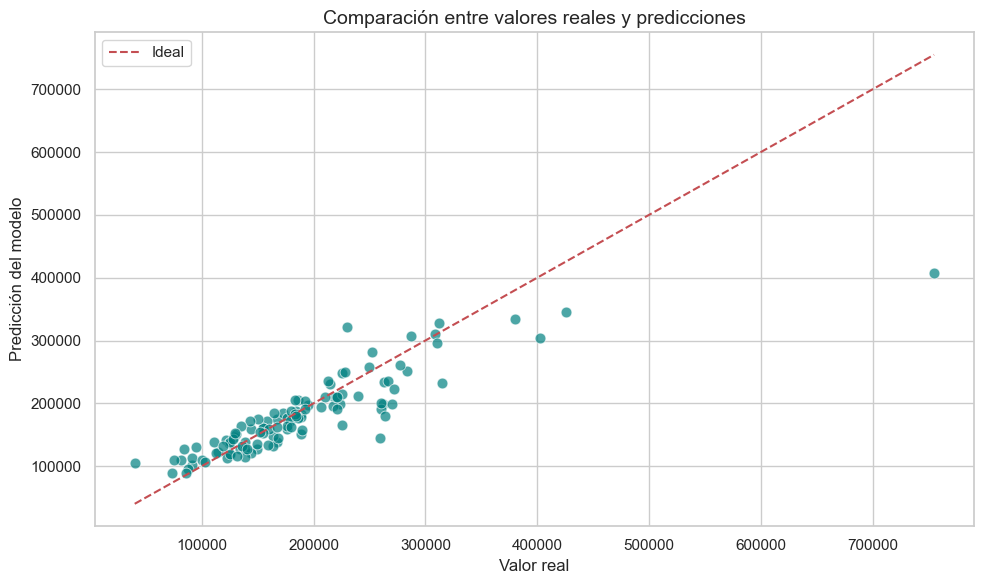

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear DataFrame para comparar fácilmente
df_resultados = pd.DataFrame({
    "Real": y_test,
    "Predicción": y_pred
})

# Estilo visual
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Gráfico de dispersión con línea de referencia
sns.scatterplot(data=df_resultados, x="Real", y="Predicción", alpha=0.7, color="teal", s=60)
plt.plot([df_resultados.min().min(), df_resultados.max().max()],
         [df_resultados.min().min(), df_resultados.max().max()],
         'r--', label="Ideal")

plt.title("Comparación entre valores reales y predicciones", fontsize=14)
plt.xlabel("Valor real", fontsize=12)
plt.ylabel("Predicción del modelo", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Conclusiones

- Se ha implementado y entrenado un meta-modelo de ensamble secuencial basado en árboles de decisión, capaz de corregir iterativamente los errores de predicción.
- La estandarización de las variables predictoras contribuyó a un entrenamiento estable y efectivo del modelo.
- El modelo alcanzó un coeficiente de determinación R² de aproximadamente 0.73, lo que indica que explica el 73% de la variabilidad en los datos de prueba del conjunto House_price.
- Esta metodología permite mejorar el rendimiento respecto a modelos individuales simples al combinar múltiples modelos especializados en errores residuales.
- En la gráfica entre las predicciones del modelo y los valores reales en el conjunto de prueba podemos observar como se tiende a seguir la diagonal ideal (*y = x*), confirmando una buena capacidad predictiva. La mayoría de los puntos se agrupan cerca de esta línea, lo que indica un bajo error de predicción en muchos casos, exceptuando casos aislados.
- Además, la tabla con los ejemplos reales y sus correspondientes predicciones permite comprobar numéricamente la proximidad entre ambos valores, reforzando visualmente la consistencia del modelo.
- En siguientes etapas, se explorará el ajuste de hiperparámetros, validación cruzada y la aplicación a otros conjuntos de datos para consolidar la robustez y generalización del modelo.